(P:lab21)=
# Convolution

## Calculating a convolution by hand

Consider the image

$$
x =
\begin{pmatrix}
1 & 1 & 0 & 0 \\
1 & 1 & 0 & 0
\end{pmatrix}
$$

* Calculate by hand the convolution of $x$ with $h_1=\begin{pmatrix}1 & -1\end{pmatrix}$.
* Calculate by hand the convolution of $x$ with $h_2=\begin{pmatrix}1 & -1\end{pmatrix}^T$.
* Calculate by hand the convolution of $x$ with $h_3=\begin{pmatrix}1 & 2 & 1\end{pmatrix}$.

## Computing the convolution between two images

The image {download}`smiley.png` will be convolved with several PSF.
Before applying the convolutions, you need to convert the image into float (`skimage.img_as_float`).

::::{note}
It can be very useful for analyzing the results to display the colorbar alongside each image.
You can follow the code below
(`img` is the image to show):

:::python
import matplotlib.pyplot as plt

plt.figure()
ax = plt.imshow(img, "gray")
plt.colorbar(ax)
plt.show()
:::
::::

* What does the acronym PSF stand for?

* Compute the convolution between the image and a Gaussian kernel (`skimage.filters.gaussian`).

* Compute the convolution between the image and the kernel defined by

  $$
    h = \begin{pmatrix} 1 & -1 \end{pmatrix},
  $$
  
  by using `scipy.ndimage.convolve` and initializing $h$ with `numpy.array`.
  Note that $h$ being an image, it should be defined as a 2D matrix!
  
  <!--
    `scipy.ndimage.convolve` est plus adapté que `scipy.signal.convolve2d` pour le traitement d'image.
    En effet, il n'est pas nécessaire de définir l'option 'same' (le résultat a tout de suite la même taille que l'entrée)
    et de plus on peut définir l'hypothèse sur les bords.
   -->
  
* Compute the convolution between the image and a kernel defined by an array of 30 elements equal to 1/30
  (`numpy.ones`).

* * *

## Correction

**📌 Commentaires pour les intervenants**

* Conseillez aux étudiants de représenter les PSF, en plus du résultat de la convolution.
  Laissez-les réfléchir un peu pour savoir comment ils peuvent s'y prendre
  (sachant que pour la gaussienne, on n'utilise pas une matrice, mais la fonction `gaussian`).
  L'idée est de convoluer un dirac (qu'il faut alors créer !).
  Cette idée est donnée dans la correction.

* Beaucoup d'étudiants risque de ne pas oublier les deux paires de crochets pour définir la deuxième PSF : `h = np.array([[1, -1]])`.
  Dans ce cas, on peut leur donner la solution assez rapidement.
  
* Ils peuvent également essayer d'utiliser d'autres PSF.

In [1]:
import numpy as np
import scipy as sp
import skimage as ski
import skimage.io as io
import skimage.filters as flt
import matplotlib.pyplot as plt

### Objectives

* Know how to use the function `scipy.ndimage.convolve` to apply the convolution product.
* Be able to identify the kernel applied on a convolved image.

## Calculating a convolution by hand

The convolution is commutative: $f_1 = h_1 * x = x * h_1$ and is defined as:

$$
  f_1(y,x) = \sum_m \sum_n   x(y-m,x-n) h_1(m,n)
$$

To apply the convolution product, it is necessary to define an origin in the images $h_1$ and $x$.
Suppose that the origin is given by the red pixel:

$$
x =
\begin{pmatrix}
\color{red}{1} & 1 & 0 & 0 \\
1 & 1 & 0 & 0
\end{pmatrix}
\quad\text{and}\quad
h_1=\begin{pmatrix}\color{red}{1} & -1\end{pmatrix}.
$$

Note that $h_1$ has only two non-zero pixels: $h_1(0,0)=1$ and $h_1(0,1)=-1$.
Then we have:

$$
f_1 =
\begin{pmatrix}
? & 0 & -1 & 0 \\
? & 0 & -1 & 0
\end{pmatrix}
$$

:::{dropdown} Proof

Consider the first pixel $(0,0)$:

$$
  f_1(0,0) = \sum_m \sum_n x(0-m,0-n) h_1(m,n)
$$

Because $h$ has only two non-zero pixels, we have:

$$
  f_1(0,0)
  &= x(0-0,0-0) \times h_1(0,0) + x(0-0,0-1) \times h_1(0,1) \\
  &= x(0,0) \times h_1(0,0) + x(0,-1) \times h_1(0,1) \\
  &= 1 \times 1 + ? \times -1 \\
  &= \ ?
$$

The pixel $(0,0)$ of $f_1$ cannot be calculated because it needs the value $x(0,-1)$ which is not defined.

In the same way, we have:

$$
  f_1(0,1)
  &= x(0-0,1-0) \times h_1(0,0) + x(0-0,1-1) \times h_1(0,1) \\
  &= 1 \times 1 + 1 \times -1 \\
  &= 0
$$

$$
  f_1(0,2)
  &= x(0-0,2-0) \times h_1(0,0) + x(0-0,2-1) \times h_1(0,1) \\
  &= 0 \times 1 + 1 \times -1 \\
  &= -1
$$

$$
  f_1(0,3)
  &= x(0-0,3-0) \times h_1(0,0) + x(0-0,3-1) \times h_1(0,1) \\
  &= 0 \times 1 + 0 \times -1 \\
  &= 0
$$

We obtain similar results fot the second row of $f$.

:::

As well, considering that $1$ is the pixel at the origin in $h_2$, we obtain:

$$
f_2 =
\begin{pmatrix}
? & ? & ? & ? \\
0 & 0 & 0 & 0
\end{pmatrix},
$$

and, considering that $2$ is the pixel at the origin in $h_3$, we obtain:

$$
f_2 =
\begin{pmatrix}
? & 3 & 1 & ? \\
? & 3 & 1 & ?
\end{pmatrix}.
$$

## Computing the convolution between two images

### The point spread functions

Before convolving the image by the different filters, it is interesting to display the filters themselves.
In case there is no explicit matrix to represent a filter, as with the Gaussian filter `skimage.filters.gaussian`,
we can simply convolve the filter by an image containing only one non-zero pixel,
(this image is sometimes denoted $\delta$).

The function `skimage.filters.gaussian` defines a Gaussian kernel.
The result of the function is the convolution product of this Gaussian kernel with the image given as a parameter of the function.

The two last kernels are defined with (note the double brackets, so as to get a 2D array):

In [12]:
h = np.array([[1, -1]])

and

In [13]:
N = 30
h = np.ones((1,N)) / N

### The convolutions

The results of the convolutions are shown below, for both the $\delta$ (first row) and the smiley (second row).

In [14]:
# Filtres à appliquer

def identity(f):
    return f

def gauss(f):
    return flt.gaussian(f,4)

def diff(f):
    h = np.array([[1, -1]])
    return sp.ndimage.convolve(f, h)

def mouv(f):
    N = 30 # longueur du filtre
    h = np.ones((1,N)) / N
    return sp.ndimage.convolve(f, h)

def duplicate(f):
    h = np.zeros((10,1))
    h[0,] = 1
    h[9,] = 1
    return sp.ndimage.convolve(f, h)

# Dictionnaire des convolutions
convs = {
    "Image": identity,
    "Gaussian blur": gauss,
    "Gradient": diff,
    "Motion blur": mouv,
    #"Dédoublement": duplicate
}

K = len(convs)

In [15]:
# Images

# Dirac
img1 = np.zeros((100,100))
img1[50,50] = 1

# Smiley
img2 = io.imread('smiley.png')
img2 = ski.img_as_float(img2)

# Liste des images
images = [img1, img2]

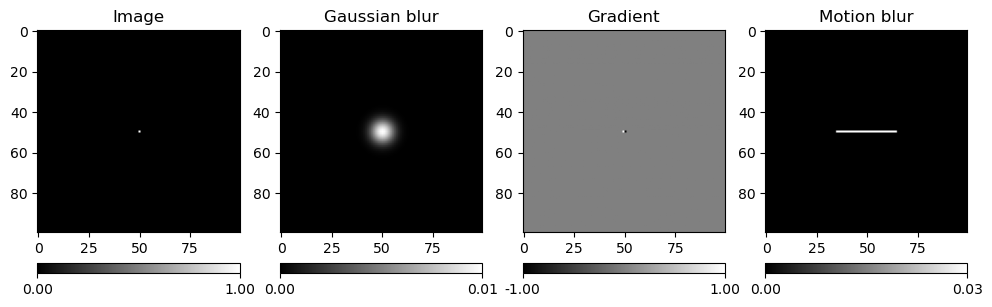

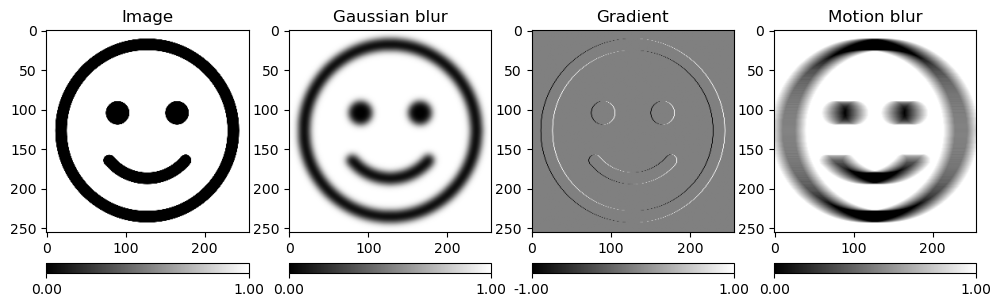

In [16]:
# Convolutions

# Boucle sur les images
for f in images:
    
    # Nouvelle figure
    fig = plt.figure(figsize=(12,8))
    i = 0
    
    # Boucle sur les convolution
    for name,c in convs.items():

        i = i + 1
        ax = plt.subplot(1,K,i)
        psm = plt.imshow(c(f), cmap="gray")
        plt.title(name)
        cbar = fig.colorbar(psm, ax=ax, orientation="horizontal",
                            pad = 0.05, shrink=1.0)
        cbar.set_ticks([ c(f).min(), c(f).max() ])
        cbar.set_ticklabels([ f"{c(f).min():.2f}" , f"{c(f).max():.2f}" ])



The "gradient" image (third image) brings out the vertical contours of the image.
We will reuse this filter in [Edge detection](https://vincmazet.github.io/bip/detection/edges).